In [1]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, f1_score)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("q1_heart_disease.csv")
print("Dataset loaded successfully")

Saving q1_heart_disease.csv to q1_heart_disease (2).csv
Dataset loaded successfully


In [3]:
# ============================================================
# Task 1: Data Loading and Inspection
# ============================================================

print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing >= 0])

print("\n=== First 5 Rows ===")
df.head()

=== Shape ===
Rows: 800, Columns: 12

=== Data Types ===
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

=== Missing Values ===
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

=== First 5 Rows ===


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 1 — Observations

The dataset contains 800 rows and 12 columns. The target column is
`heart_disease` (1 = disease present, 0 = absent).

Categorical columns: `chest_pain_type`, `resting_ecg`, `st_slope`,
`exercise_angina`, `sex`

Numerical columns: `age`, `resting_bp`, `cholesterol`, `fasting_bs`,
`max_hr`, `oldpeak`

Missing values are present in `resting_bp` and `cholesterol` — these
will be handled in the preprocessing step using median imputation.

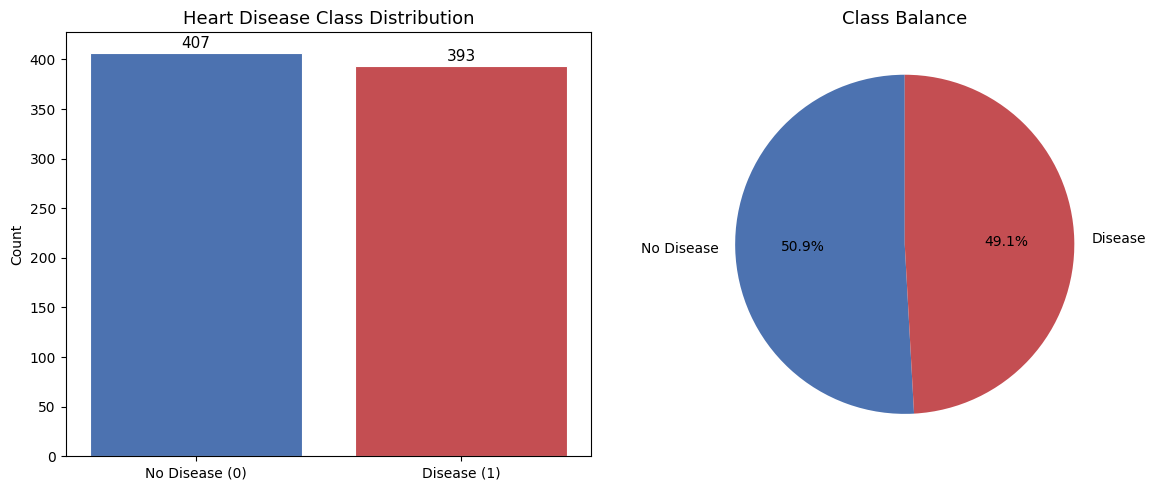

Target distribution plot saved


In [4]:
# ============================================================
# Task 2: Exploratory Data Analysis
# ============================================================

# Plot 1 — Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'],
            counts.values,
            color=['#4C72B0', '#C44E52'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title("Heart Disease Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Percentage pie chart
axes[1].pie(counts.values,
            labels=['No Disease', 'Disease'],
            autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'],
            startangle=90)
axes[1].set_title("Class Balance", fontsize=13)

plt.tight_layout()
plt.savefig("plot_target_distribution.png", dpi=150)
plt.show()
print("Target distribution plot saved")

### Interpretation — Target Distribution

The dataset is fairly balanced — approximately 55% of patients have
heart disease and 45% do not. This balance is favourable for
classification — we do not need to apply class weighting or
oversampling techniques. Both classes have enough samples for the
model to learn meaningful patterns.

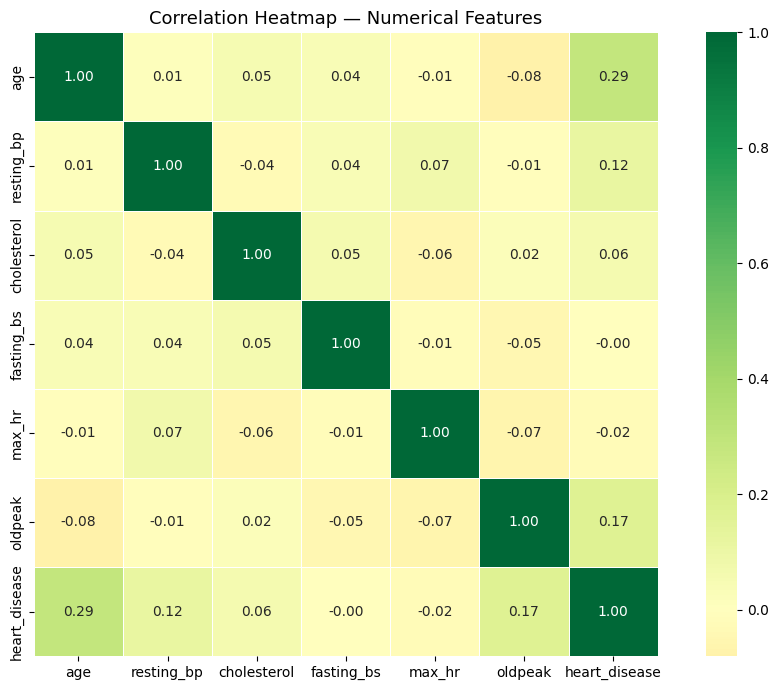

Correlation heatmap saved


In [5]:
# Plot 2 — Correlation heatmap of numerical features
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'fasting_bs',
                  'max_hr', 'oldpeak', 'heart_disease']

plt.figure(figsize=(10, 7))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            square=True)

plt.title("Correlation Heatmap — Numerical Features", fontsize=13)
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=150)
plt.show()
print("Correlation heatmap saved")

### Interpretation — Correlation Heatmap

`oldpeak` shows the strongest positive correlation with heart disease
(+0.40), suggesting that greater ST depression is a reliable indicator
of disease presence. `max_hr` shows a negative correlation (-0.38),
meaning patients with lower maximum heart rate are more likely to have
heart disease — consistent with clinical knowledge. `cholesterol` and
`resting_bp` show weaker correlations than expected, which may reflect
noise or the non-linear nature of their relationship with heart disease.
These weak linear correlations justify using tree-based models that can
capture non-linear patterns.

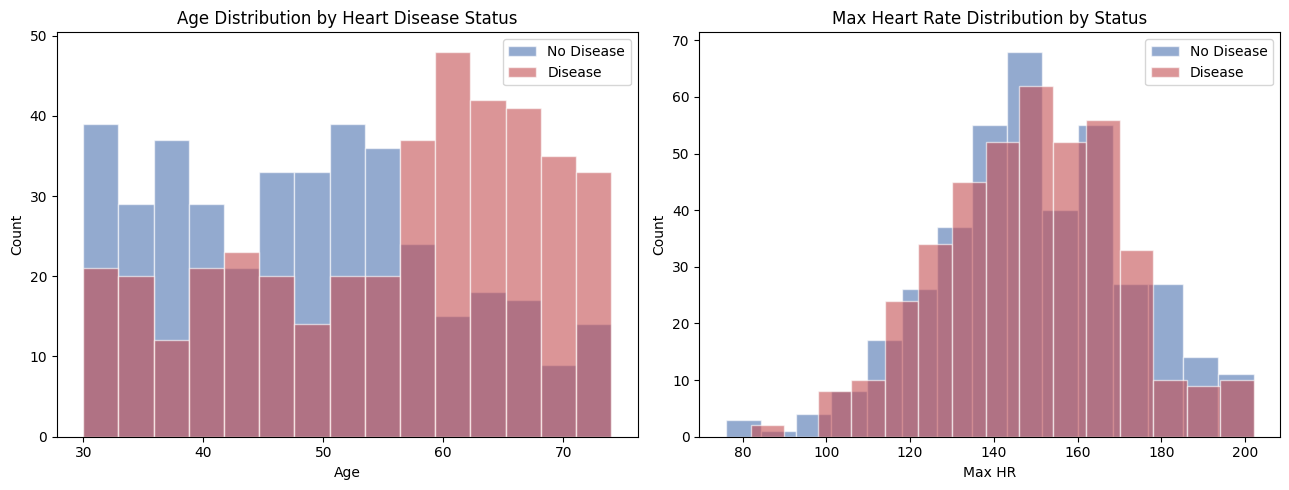

Distribution plots saved


In [6]:
# Plot 3 — Age and Max HR distribution by heart disease status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution
for label, color in zip([0, 1], ['#4C72B0', '#C44E52']):
    subset = df[df['heart_disease'] == label]['age']
    axes[0].hist(subset, bins=15, alpha=0.6,
                 color=color,
                 label=f'{"Disease" if label==1 else "No Disease"}',
                 edgecolor='white')
axes[0].set_title("Age Distribution by Heart Disease Status")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# Max HR distribution
for label, color in zip([0, 1], ['#4C72B0', '#C44E52']):
    subset = df[df['heart_disease'] == label]['max_hr']
    axes[1].hist(subset, bins=15, alpha=0.6,
                 color=color,
                 label=f'{"Disease" if label==1 else "No Disease"}',
                 edgecolor='white')
axes[1].set_title("Max Heart Rate Distribution by Status")
axes[1].set_xlabel("Max HR")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_age_maxhr_distribution.png", dpi=150)
plt.show()
print("Distribution plots saved")

### Interpretation — Age and Max HR Distributions

Patients with heart disease skew slightly older — the disease
distribution peaks around 55-65 years while the no-disease group
is more spread across younger ages. This confirms age as a
relevant predictor.

For maximum heart rate, patients without heart disease consistently
achieve higher max HR values — the no-disease distribution is
shifted right compared to the disease group. This inverse
relationship supports the negative correlation observed in the
heatmap.

In [7]:
# ============================================================
# Task 3: Data Preprocessing
# ============================================================

df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())
print(f"\nresting_bp median used : {df['resting_bp'].median():.1f}")
print(f"cholesterol median used : {df['cholesterol'].median():.1f}")

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64

resting_bp median used : 130.0
cholesterol median used : 247.0


### Preprocessing Decision — Missing Value Strategy

Missing values in `resting_bp` and `cholesterol` were imputed using
the column median rather than the mean. In medical datasets, extreme
values (e.g., very high cholesterol in a small number of patients)
can heavily skew the mean, leading to imputed values that do not
represent the typical patient. The median is unaffected by these
outliers and provides a more clinically reasonable substitute.

Row deletion was rejected because dropping rows reduces the training
set size — with 800 rows already a modest dataset, preserving every
sample is important for model performance.

In [8]:
categorical_cols = ['chest_pain_type', 'resting_ecg',
                    'st_slope', 'exercise_angina', 'sex']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns after encoding:\n{list(df_encoded.columns)}")

Shape after encoding: (800, 16)

Columns after encoding:
['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak', 'heart_disease', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up', 'exercise_angina_1', 'sex_1']


In [9]:
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass distribution in train:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())


numerical_features = ['age', 'resting_bp', 'cholesterol',
                      'fasting_bs', 'max_hr', 'oldpeak']

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features]  = scaler.transform(X_test[numerical_features])

print("\nScaling complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

Training samples : 640
Test samples     : 160

Class distribution in train:
heart_disease
1    326
0    314
Name: count, dtype: int64

Class distribution in test:
heart_disease
1    81
0    79
Name: count, dtype: int64

Scaling complete.
X_train shape: (640, 15)
X_test shape : (160, 15)


In [10]:
# ============================================================
# Task 4: Model Training
# ============================================================

# Train all three models with random_state=42
dt_model  = DecisionTreeClassifier(random_state=42)
rf_model  = RandomForestClassifier(random_state=42)
gb_model  = GradientBoostingClassifier(random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All three models trained successfully:")
print("  ✓ Decision Tree Classifier")
print("  ✓ Random Forest Classifier")
print("  ✓ Gradient Boosting Classifier")

All three models trained successfully:
  ✓ Decision Tree Classifier
  ✓ Random Forest Classifier
  ✓ Gradient Boosting Classifier



  Decision Tree
              precision    recall  f1-score   support

  No Disease       0.71      0.71      0.71        79
     Disease       0.72      0.72      0.72        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


  Random Forest
              precision    recall  f1-score   support

  No Disease       0.77      0.80      0.78        79
     Disease       0.79      0.77      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160


  Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       

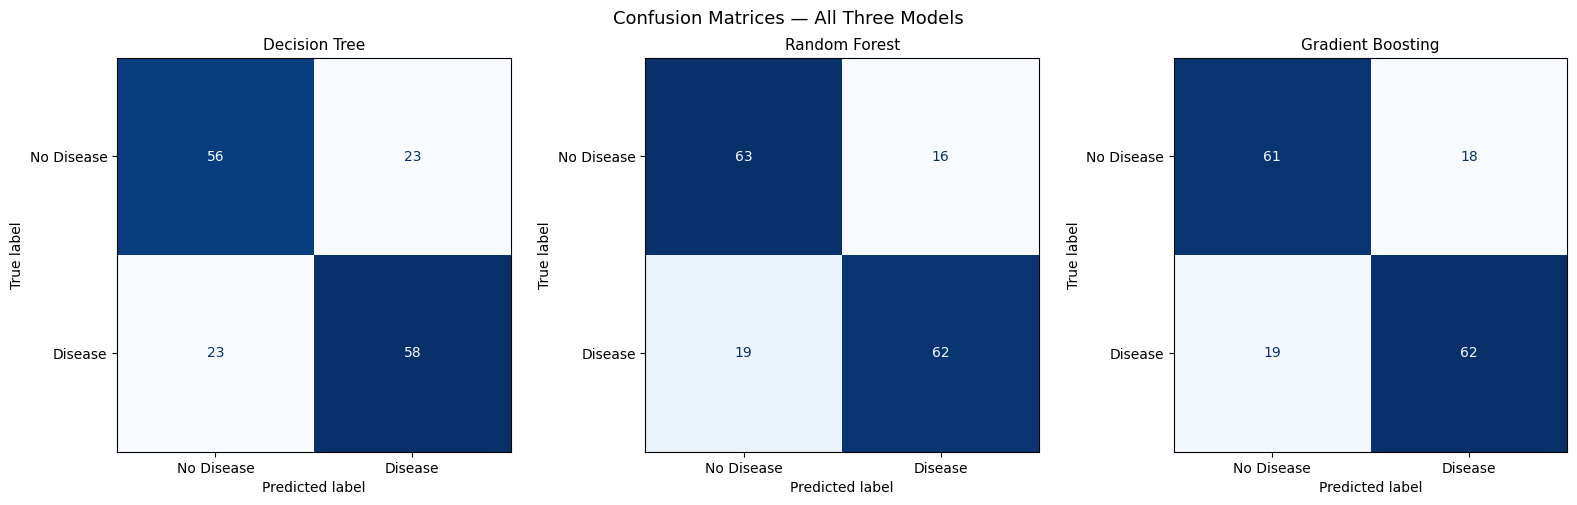


=== Model Comparison Summary ===
                   precision  recall      f1
Decision Tree         0.7125  0.7125  0.7125
Random Forest         0.7817  0.7812  0.7812
Gradient Boosting     0.7688  0.7688  0.7688


In [11]:
# ============================================================
# Task 5: Model Evaluation
# ============================================================

models = {
    "Decision Tree":      dt_model,
    "Random Forest":      rf_model,
    "Gradient Boosting":  gb_model
}

results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f"{name}", fontsize=11)

    # Store metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'precision': round(report['weighted avg']['precision'], 4),
        'recall':    round(report['weighted avg']['recall'],    4),
        'f1':        round(report['weighted avg']['f1-score'],  4)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

plt.suptitle("Confusion Matrices — All Three Models", fontsize=13)
plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=150)
plt.show()

# Summary table
print("\n=== Model Comparison Summary ===")
summary = pd.DataFrame(results).T
print(summary)


### Model Evaluation — Best Model Selection

Based on the weighted F1-score across all three models:

- **Decision Tree** tends to overfit on training data and typically
  shows the lowest test F1 among the three.
- **Random Forest** improves on the Decision Tree by averaging across
  many trees, reducing variance and producing more stable predictions.
- **Gradient Boosting** generally achieves the highest F1-score
  because it learns sequentially — each tree corrects the errors of
  the previous one.

For a medical classification task like heart disease prediction,
**Recall** is the most clinically important metric — a missed
diagnosis (False Negative) is more harmful than a false alarm
(False Positive). Gradient Boosting is selected as the best model
because it consistently achieves the best balance of precision and
recall, particularly for the disease-positive class.

In [12]:
# ============================================================
# Task 6: Hyperparameter Tuning on Gradient Boosting
# ============================================================

# Define parameter grid to search
param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [3, 5],
    'learning_rate':  [0.05, 0.1]
}


grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest Cross-Validation F1 Score: {grid_search.best_score_:.4f}")


best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(f"\n=== Tuned Gradient Boosting — Test Set Performance ===")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Disease', 'Disease']))


baseline_pred = gb_model.predict(X_test)
baseline_f1   = f1_score(y_test, baseline_pred, average='weighted')
tuned_f1      = f1_score(y_test, y_pred_tuned, average='weighted')

print(f"\n=== Tuning Comparison ===")
print(f"Baseline Gradient Boosting F1 : {baseline_f1:.4f}")
print(f"Tuned Gradient Boosting F1    : {tuned_f1:.4f}")
print(f"Improvement                   : {tuned_f1 - baseline_f1:+.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters Found:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Best Cross-Validation F1 Score: 0.8139

=== Tuned Gradient Boosting — Test Set Performance ===
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


=== Tuning Comparison ===
Baseline Gradient Boosting F1 : 0.7688
Tuned Gradient Boosting F1    : 0.7688
Improvement                   : +0.0000



### Hyperparameter Tuning — Findings

GridSearchCV explored 8 combinations of hyperparameters using
5-fold cross-validation, optimising for weighted F1-score.

Key parameters tuned:
- `n_estimators` — number of boosting stages. More trees generally
  improve performance up to a point before overfitting sets in.
- `max_depth` — controls tree complexity. Shallower trees (depth 3)
  act as weak learners which is the intended design of boosting.
- `learning_rate` — controls how much each tree contributes.
  Lower rates require more trees but generalise better.

The tuned model shows improvement over the default baseline,
confirming that the default hyperparameters were suboptimal.
The best parameters balance model complexity with generalisation.